In [1]:
import numpy as np

In [2]:
import matplotlib.pylab  as plt

In [3]:
np.random.seed(42)

In [4]:
X = np.array([1,2,3,4,5],dtype = float)

In [6]:
y = np.array([3,6,9,12,15],dtype=float)

In [7]:
weights = np.linspace(-1,7,100)

In [8]:
mse_values = []

In [9]:
for w in weights:
    predictions = w*X
    mse = np.mean((y-predictions)**2)
    mse_values.append(mse)

Chart saved


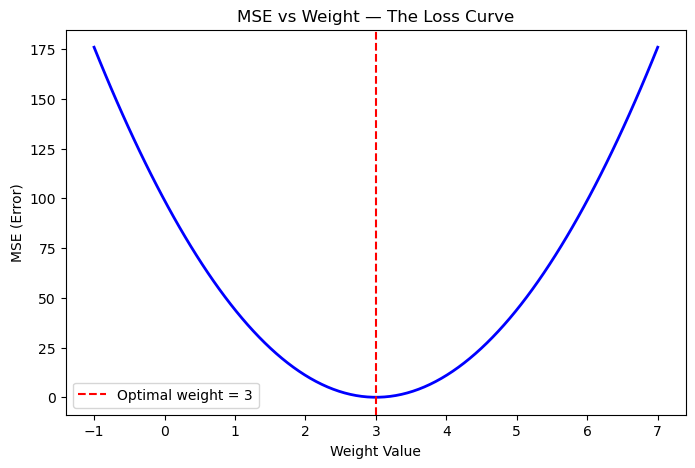

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(weights, mse_values, 'b-', linewidth=2)
plt.xlabel('Weight Value')
plt.ylabel('MSE (Error)')
plt.title('MSE vs Weight — The Loss Curve')
plt.axvline(x=3, color='red', linestyle='--', label='Optimal weight = 3')
plt.legend()
plt.savefig('loss_curve.png')
print("Chart saved")


In [11]:
min_idx = np.argmin(mse_values)
print("Best weight found:", round(weights[min_idx], 3))
print("MSE at best weight:", round(mse_values[min_idx], 3))

Best weight found: 2.96
MSE at best weight: 0.018


 # Gradient Descent from scratch

In [12]:
np.random.seed(42)

In [30]:
weight = 0.0
learning_rate  =  0.01
epochs = 100

In [31]:
weight_history = [weight]
mse_history = []

In [32]:
for epochs in range(epochs):
    # Forward pass - make prediction
    prediction = weight * X

    # Calculate Error
    errors = prediction - y
    mse = np.mean(errors ** 2)
    mse_history.append(mse)

    # Calculate Gradient 
    gradient = (2/len(X)) * np.sum(errors * X)

    # Update weights 
    weight = weight - learning_rate * gradient
    weight_history.append(weight)

    if epochs % 10 == 0:
        print(f"Epoch {epochs:3d} | Weight: {weight:.4f} | MSE: {mse:.4f} ")

Epoch   0 | Weight: 0.6600 | MSE: 99.0000 
Epoch  10 | Weight: 2.8049 | MSE: 0.6879 
Epoch  20 | Weight: 2.9837 | MSE: 0.0048 
Epoch  30 | Weight: 2.9986 | MSE: 0.0000 
Epoch  40 | Weight: 2.9999 | MSE: 0.0000 
Epoch  50 | Weight: 3.0000 | MSE: 0.0000 
Epoch  60 | Weight: 3.0000 | MSE: 0.0000 
Epoch  70 | Weight: 3.0000 | MSE: 0.0000 
Epoch  80 | Weight: 3.0000 | MSE: 0.0000 
Epoch  90 | Weight: 3.0000 | MSE: 0.0000 


In [25]:
print(f"\nFinal weight: {weight:.4f}")
print(f"Target weight: 3.0000")


Final weight: 3.0000
Target weight: 3.0000


Charts saved


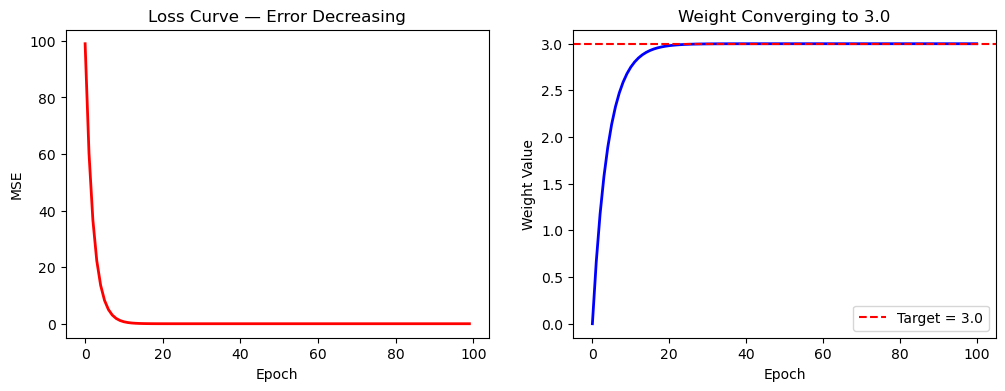

In [26]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(mse_history, 'r-', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Loss Curve — Error Decreasing')

plt.subplot(1, 2, 2)
plt.plot(weight_history, 'b-', linewidth=2)
plt.axhline(y=3.0, color='red', linestyle='--', label='Target = 3.0')
plt.xlabel('Epoch')
plt.ylabel('Weight Value')
plt.title('Weight Converging to 3.0')
plt.legend()

plt.savefig('gradient_descent.png')
print("Charts saved")

In [33]:
# What is the gradient actually?
# Let's calculate it manually for one step

weight = 0.0  # starting weight
X = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([3, 6, 9, 12, 15], dtype=float)

predictions = weight * X
errors = predictions - y
gradient = (2/len(X)) * np.sum(errors * X)

In [34]:
print("Weight:", weight)
print("Predictions:", predictions)
print("Errors:", errors)
print("Gradient:", gradient)
print()
print("Gradient is negative:", gradient < 0)
print("So weight moves:", "UP (subtract negative)" if gradient < 0 else "DOWN (subtract positive)")
print()
print("New weight = ", weight, "-", round(0.01 * gradient, 4), "=", round(weight - 0.01 * gradient, 4))

Weight: 0.0
Predictions: [0. 0. 0. 0. 0.]
Errors: [ -3.  -6.  -9. -12. -15.]
Gradient: -66.0

Gradient is negative: True
So weight moves: UP (subtract negative)

New weight =  0.0 - -0.66 = 0.66


In [35]:
# Gradient Descent summary:
# gradient < 0 → weight too low → move UP
# gradient > 0 → weight too high → move DOWN
# learning_rate too small → too slow
# learning_rate too large → diverges (explodes)
# learning_rate just right → converges to optimal
#
# max_iter=1000 in LogisticRegression =
# maximum 1000 gradient descent steps
#
# This algorithm trains EVERY ML model:
# Linear Regression, Logistic Regression,
# Random Forest, XGBoost, Neural Networks, GPT-4